# Занятие 12. PINN для стационарных задач (ОДУ) #

На этом занятии мы применим метод PINN для решения стационарного уравнения Бюргерса.
Это нелинейное обыкновенное дифференциальное уравнение (ОДУ), которое описывает структуру ударной волны.
Мы переходим от 1D+Time к чистому 1D, чтобы сосредоточиться на сходимости к точному аналитическому решению.

### Уравнение:
$$ u \frac{du}{dx} - \nu \frac{d^2u}{dx^2} = 0, \quad x \in [-1, 1] $$

### Граничные условия:
$$ u(-1) = 1, \quad u(1) = -1 $$

### Аналитическое решение:
Известно точное решение этой краевой задачи:
$$ u(x) = -\tanh\left(\frac{x}{2\nu}\right) $$

Это идеальный полигон ("дрозофила") для PINN: мы знаем ответ, уравнение нелинейное, есть параметр $\nu$, отвечающий за крутизну фронта.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time

# Выбираем устройство
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)
np.random.seed(42)

print(f"Вычисления на: {device}")

Вычисления на: cuda


## 1. Нейросеть (Аппроксиматор) ##

In [2]:
class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Вход: 1 нейрон (координата x)
        # Выход: 1 нейрон (значение u)
        # Для этой задачи достаточно небольшой сети
        self.net = nn.Sequential(
            nn.Linear(1, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )
        
        # Инициализация весов
        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)

    def forward(self, x):
        return self.net(x)

## 2. Физика (Physics Loss) ##

In [14]:
def physics_loss(model, x, nu):
    """
    Невязка уравнения: u * u' - nu * u'' = 0
    """
    x.requires_grad = True
    
    u = model(x)
    
    # Первая производная u_x
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    
    # Вторая производная u_xx
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    
    # Невязка
    residual = u * u_x - nu * u_xx
    
    return torch.max(residual ** 2)

## 3. Генерация данных ##

In [15]:
def generate_data(n_bnd, n_col):
    """
    n_bnd: число точек на границах
    n_col: число точек коллокации внутри интервала
    """
    
    # 1. Граничные точки (Boundary Points)
    # Левая граница: x = -1, u = 1
    x_left = -1.0 * torch.ones(n_bnd // 2, 1)
    u_left =  1.0 * torch.ones(n_bnd // 2, 1)
    
    # Правая граница: x = 1, u = -1
    x_right = 1.0 * torch.ones(n_bnd // 2, 1)
    u_right = -1.0 * torch.ones(n_bnd // 2, 1)
    
    X_bnd = torch.cat([x_left, x_right])
    U_bnd = torch.cat([u_left, u_right])
    
    # 2. Точки коллокации (Collocation Points)
    # Случайные точки в интервале [-1, 1]
    X_col = (torch.rand(n_col, 1) * 2.0 - 1.0)
    
    return X_bnd.to(device), U_bnd.to(device), X_col.to(device)

## 4. Обучение ##

In [ ]:
def train():
    # Параметры
    NU = 0.05       # Вязкость (чем меньше, тем круче ступенька)
    EPOCHS = 3501   # Количество итераций
    LR = 0.001      # Learning Rate
    
    model = PINN().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    
    # Генерируем данные один раз (хотя можно и обновлять каждую эпоху)
    x_bnd, u_bnd, x_col = generate_data(n_bnd=100, n_col=2000)
    
    history = []
    start_time = time.time()
    
    print(f"Обучение: Nu={NU}, Epochs={EPOCHS}")
    
    for epoch in range(EPOCHS):
        optimizer.zero_grad()
        
        # 1. Ошибка на границах (Data Loss)
        u_pred_bnd = model(x_bnd)
        loss_bnd = torch.max((u_pred_bnd - u_bnd)**2)
        
        # 2. Ошибка уравнения (Physics Loss)
        loss_phys = physics_loss(model, x_col, NU)
        
        # Суммарная ошибка
        # Иногда полезно добавить веса: loss = 10*loss_bnd + loss_phys
        loss = loss_bnd + loss_phys
        
        loss.backward()
        optimizer.step()
        
        history.append(loss.item())
        
        if epoch % 500 == 0:
            print(f"Epoch {epoch:04d}: Loss={loss.item():.6f} (Bnd={loss_bnd.item():.6f}, Phys={loss_phys.item():.6f})")
            
    print(f"Время обучения: {time.time() - start_time:.2f} сек")
    return model, history, NU

In [29]:
trained_model, loss_history, NU = train()

Обучение: Nu=0.05, Epochs=4501
Epoch 0000: Loss=1.780349 (Bnd=1.779979, Phys=0.000370)
Epoch 0500: Loss=0.177952 (Bnd=0.080495, Phys=0.097456)
Epoch 1000: Loss=0.160893 (Bnd=0.068770, Phys=0.092123)
Epoch 1500: Loss=0.068787 (Bnd=0.032032, Phys=0.036755)
Epoch 2000: Loss=0.011583 (Bnd=0.007059, Phys=0.004524)
Epoch 2500: Loss=0.004108 (Bnd=0.000209, Phys=0.003899)
Epoch 3000: Loss=0.000137 (Bnd=0.000017, Phys=0.000120)
Epoch 3500: Loss=0.001110 (Bnd=0.000037, Phys=0.001073)
Epoch 4000: Loss=0.005692 (Bnd=0.000098, Phys=0.005594)
Epoch 4500: Loss=0.000644 (Bnd=0.000008, Phys=0.000636)
Время обучения: 14.83 сек


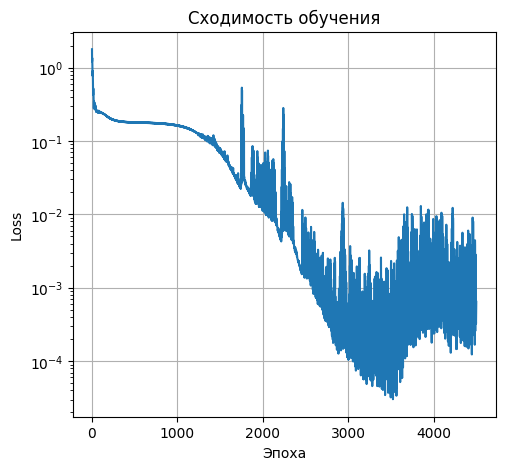

In [30]:
# 1. График Loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(loss_history)
plt.yscale('log')
plt.title('Сходимость обучения')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.grid(True)
    

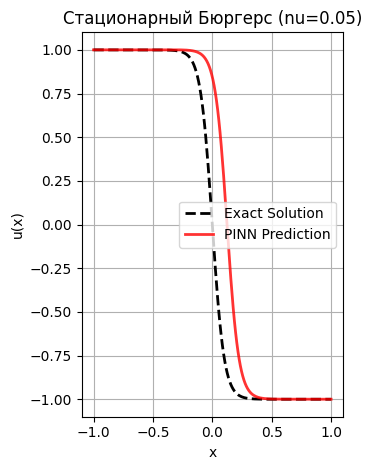

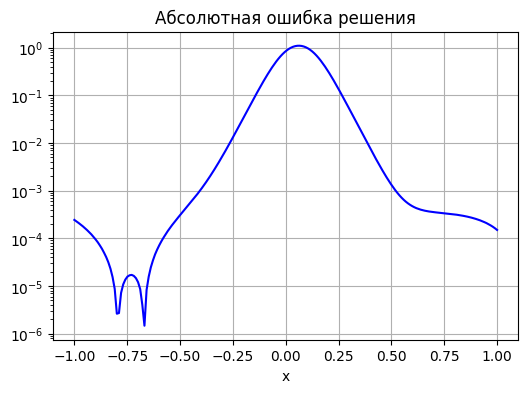

In [13]:

# 2. Сравнение решения
plt.subplot(1, 2, 2)

# Сетка для графика
x_np = np.linspace(-1, 1, 200)
x_torch = torch.tensor(x_np.reshape(-1, 1), dtype=torch.float32).to(device)

# Предсказание нейросети
with torch.no_grad():
    u_pred = trained_model(x_torch).cpu().numpy()
    
# Аналитическое решение
# u = -tanh(x / 2nu)
u_exact = -np.tanh(x_np / (2 * NU))

plt.plot(x_np, u_exact, 'k--', linewidth=2, label='Exact Solution')
plt.plot(x_np, u_pred, 'r-', linewidth=2, alpha=0.8, label='PINN Prediction')

plt.title(f'Стационарный Бюргерс (nu={NU})')
plt.xlabel('x')
plt.ylabel('u(x)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# График ошибки
plt.figure(figsize=(6, 4))
plt.plot(x_np, np.abs(u_exact - u_pred.flatten()), 'b-')
plt.title('Абсолютная ошибка решения')
plt.xlabel('x')
plt.yscale('log')
plt.grid(True)
plt.show()